Q1.1

In [84]:
import numpy as np

In [85]:
arr=np.linspace(0,20,100)
print(arr)

[ 0.          0.2020202   0.4040404   0.60606061  0.80808081  1.01010101
  1.21212121  1.41414141  1.61616162  1.81818182  2.02020202  2.22222222
  2.42424242  2.62626263  2.82828283  3.03030303  3.23232323  3.43434343
  3.63636364  3.83838384  4.04040404  4.24242424  4.44444444  4.64646465
  4.84848485  5.05050505  5.25252525  5.45454545  5.65656566  5.85858586
  6.06060606  6.26262626  6.46464646  6.66666667  6.86868687  7.07070707
  7.27272727  7.47474747  7.67676768  7.87878788  8.08080808  8.28282828
  8.48484848  8.68686869  8.88888889  9.09090909  9.29292929  9.49494949
  9.6969697   9.8989899  10.1010101  10.3030303  10.50505051 10.70707071
 10.90909091 11.11111111 11.31313131 11.51515152 11.71717172 11.91919192
 12.12121212 12.32323232 12.52525253 12.72727273 12.92929293 13.13131313
 13.33333333 13.53535354 13.73737374 13.93939394 14.14141414 14.34343434
 14.54545455 14.74747475 14.94949495 15.15151515 15.35353535 15.55555556
 15.75757576 15.95959596 16.16161616 16.36363636 16

In [86]:
mean=np.mean(arr)
print(mean)

10.0


In [87]:
median=np.median(arr)
print(median)

10.0


In [88]:
standard_deviation=np.std(arr)
print(standard_deviation)

5.831529302570125


In [89]:
variance=np.var(arr)
print(variance)

34.00673400673401


Q1.2

In [90]:
A=np.linspace(1,36,36,dtype=int)
print(A)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]


In [91]:
B=np.reshape(A,(4,9))
print(B.shape)

(4, 9)


In [92]:
C=B.flatten()
print(C.shape)

(36,)


Q2.1

In [93]:
import seaborn as sns
df=sns.load_dataset('titanic')

In [94]:
print(df.head(5))

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [95]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [97]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [98]:
(df.isnull().sum()/len(df))*100

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.224467
class,0.000000
who,0.000000


In [99]:
df['age'] = df['age'].fillna(
    df.groupby('pclass')['age'].transform('median')
)

df['embarked'] = df['embarked'].fillna(
    df['embarked'].mode()[0]
)

df.drop(columns='deck', inplace=True)

print(df[['age','embarked']].isnull().sum())

age         0
embarked    0
dtype: int64


The deck column contains more than 75% missing values so dropping it is appropriate because imputing such a large proportion would introduce significant uncertainty

Q3.1

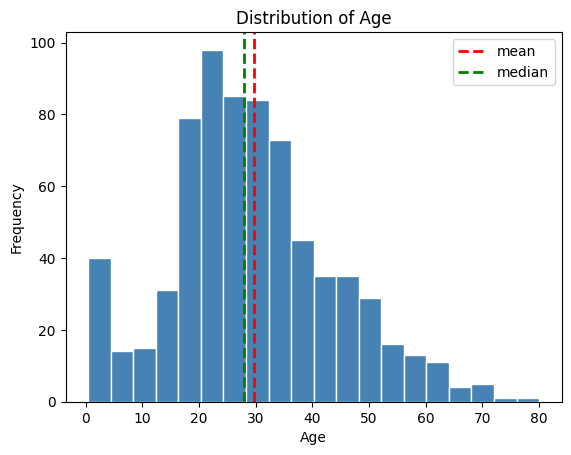

In [17]:
import matplotlib.pyplot as plt
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.axvline(df['age'].mean(), color='red', linestyle='dashed', linewidth=2, label='mean')
plt.axvline(df['age'].median(), color='green', linestyle='dashed', linewidth=2, label='median')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()


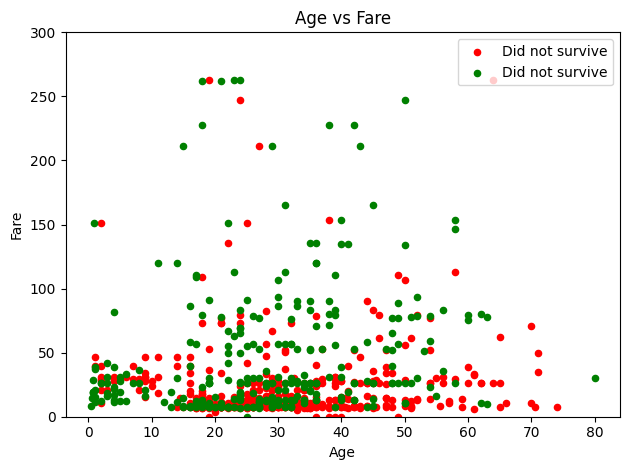

In [18]:
plt.scatter(
    df[df['survived']==0]['age'],
    df[df['survived']==0]['fare'],
    color='red',
    s=20,
    label='Did not survive'
)
plt.scatter(
    df[df['survived']==1]['age'],
    df[df['survived']==1]['fare'],
    color='green',
    s=20,
    label='Survived'
)
plt.ylim(0,300)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Fare values above 300 were excluded from visualization to improve readability and reduce the impact of extreme outliers

Q4.1

In [21]:
import pandas as pd
df=pd.read_csv("advertising.csv")
print("Shape:", df.shape)
print("\nData type:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Shape: (200, 4)

Data type:
 TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [22]:
print(df.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


TV Advertising Budget ranges from 0.7 to 296.4, with a standard deviation of 85.85, indicating a very wide spread in TV advertising expenditure.
Radio Advertising Budget ranges from 0.0 to 49.6, with a standard deviation of 14.85, showing moderate variability.
Newspaper Advertising Budget ranges from 0.3 to 114.0, with a standard deviation of 21.78, suggesting considerable variation across observations.
Sales range from 1.6 to 27.0, with a standard deviation of 5.28, indicating a moderate spread in sales values.

Overall TV has the largest range and variability among all features, while Sales exhibits a comparatively smaller spread.

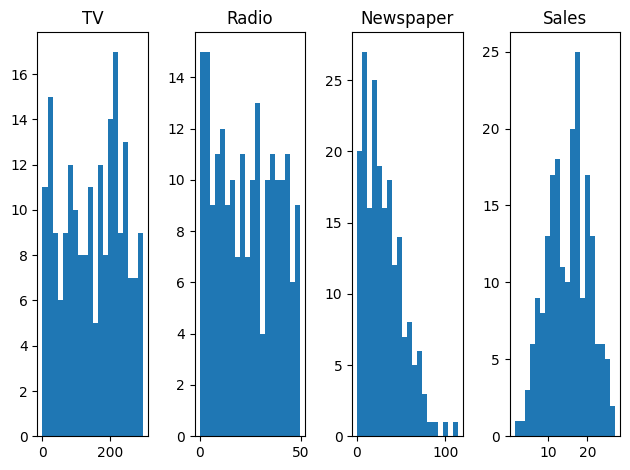

In [23]:
plt.subplot(1,4,1)
plt.hist(df['TV'], bins=20)
plt.title('TV')

plt.subplot(1,4,2)
plt.hist(df['Radio'], bins=20)
plt.title('Radio')

plt.subplot(1,4,3)
plt.hist(df['Newspaper'], bins=20)
plt.title('Newspaper')

plt.subplot(1,4,4)
plt.hist(df['Sales'], bins=20)
plt.title('Sales')

plt.tight_layout()
plt.show()


From the histograms, most of the data appears to be distributed normally. No very obvious outliers can be seen in the TV, Radio, and Sales variables.
The Newspaper variable has a few values that are much higher than most of the data points, so it may contain some possible outliers. However, there are no extreme outliers visible from the histograms.

Q4.2

In [25]:
corr_matrix = df.corr()
print(corr_matrix)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


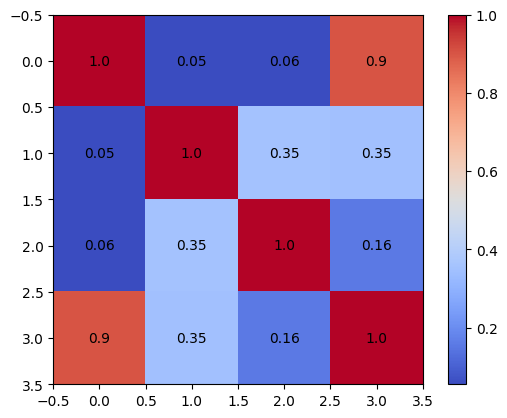

In [29]:
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()
for i in range(4):
    for j in range(4):
        plt.text(
            j,
            i,
            round(corr_matrix.iloc[i, j], 2),
            ha='center',
            va='center'
        )


TV is most correlated with sales.
And there is very weak correlation between TV and radio.

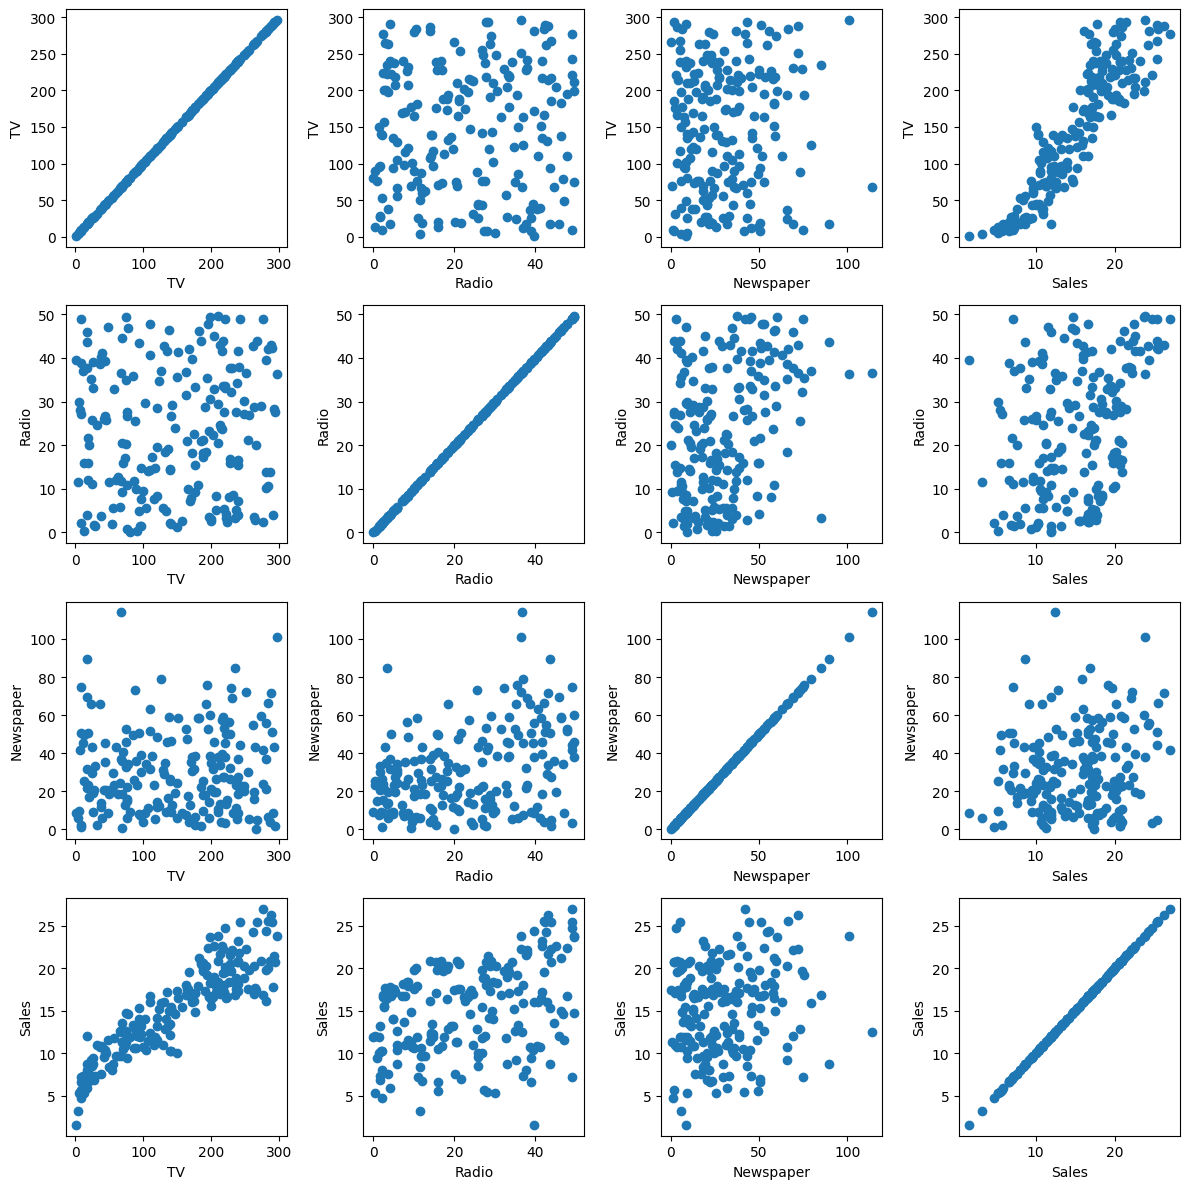

In [35]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4):
    for j in range(4):

        axes[i, j].scatter(df[df.columns[j]], df[df.columns[i]])

        axes[i, j].set_xlabel(df.columns[j])
        axes[i, j].set_ylabel(df.columns[i])

plt.tight_layout()
plt.show()

Q5.1

In [36]:
df = pd.read_csv("advertising.csv")

x = df["TV"].values
y = df["Sales"].values

x_train = x[:160]
x_test = x[160:]

y_train = y[:160]
y_test = y[160:]

In [38]:
x_bar = np.mean(x_train)
y_bar = np.mean(y_train)

In [39]:
n = np.sum((x_train - x_bar) * (y_train - y_bar))

d = np.sum((x_train - x_bar) ** 2)

m = n/d

In [40]:
b = y_bar - m * x_bar

In [44]:
print("m =",m)
print("\nb=", b)

m = 0.05572601895005874

b= 6.993686960994353


In [46]:
y_pred = m * x_test + b


In [47]:
mse = np.mean((y_test - y_pred) ** 2)

Q5.2

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x = df[["TV"]]
y = df["Sales"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

print("Coefficient (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Coefficient (m): 0.0554829439314632
Intercept (b): 7.007108428241848


The values are close because both methods implement the same linear regression algorithm. A small difference exists because Q5.1 used the first 160 rows as the training set, while Q5.2 used a random 80–20 split with train_test_split(random_state=42). Different training data can produce slightly different model parameters.

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("Training Metrics")
print("MAE:", train_mae)
print("MSE:", train_mse)
print("RMSE:", train_rmse)
print("R²:", train_r2)

print("\nTesting Metrics")
print("MAE:", test_mae)
print("MSE:", test_mse)
print("RMSE:", test_rmse)
print("R²:", test_r2)

Training Metrics
MAE: 1.8005092256620792
MSE: 4.998442356450173
RMSE: 2.235719650683013
R²: 0.8134866044709264

Testing Metrics
MAE: 1.9502948931650088
MSE: 6.101072906773963
RMSE: 2.470035001123256
R²: 0.802561303423698


The model is well fit because the the train error and test are are nearly same.

Q6.1

In [55]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [58]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


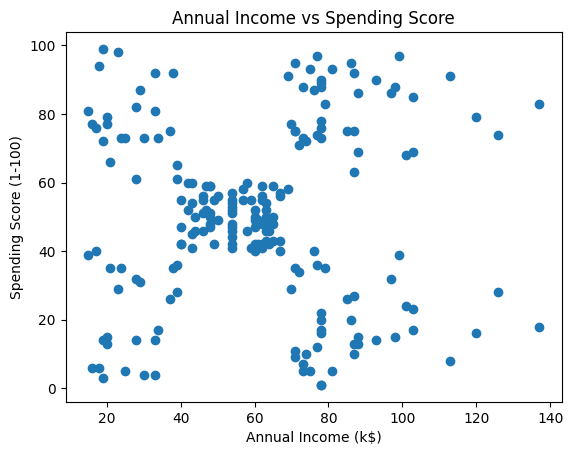

In [59]:
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')

plt.show()

Yes I can visually see  5 groupings

In [61]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

df['Cluster'] = kmeans.labels_

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

centroids.index.name = "Cluster"

print("Cluster Centroids")
print(centroids.round(2))

for cluster in sorted(df['Cluster'].unique()):

    cluster_data = df[df['Cluster'] == cluster]

    print(f"\nCluster {cluster}")
    print("Customer Count :", len(cluster_data))
    print("Mean Annual Income :", round(cluster_data['Annual Income (k$)'].mean(), 2))
    print("Mean Spending Score :", round(cluster_data['Spending Score (1-100)'].mean(), 2))

Cluster Centroids
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91

Cluster 0
Customer Count : 81
Mean Annual Income : 55.3
Mean Spending Score : 49.52

Cluster 1
Customer Count : 39
Mean Annual Income : 86.54
Mean Spending Score : 82.13

Cluster 2
Customer Count : 22
Mean Annual Income : 25.73
Mean Spending Score : 79.36

Cluster 3
Customer Count : 35
Mean Annual Income : 88.2
Mean Spending Score : 17.11

Cluster 4
Customer Count : 23
Mean Annual Income : 26.3
Mean Spending Score : 20.91


Q7.1

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


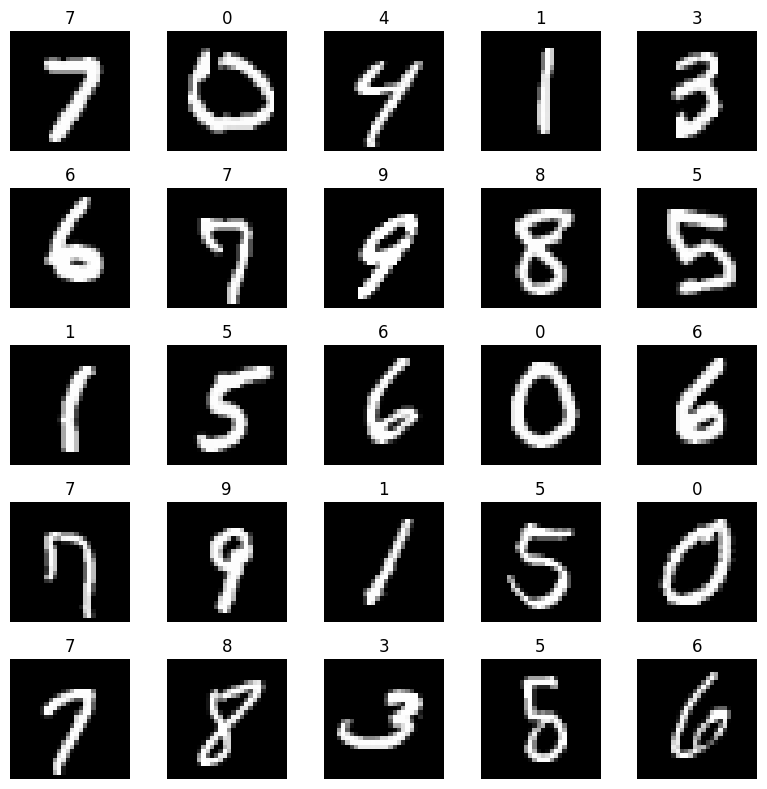

In [100]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train = X_train / 255.0
X_test = X_test / 255.0

fig, axes = plt.subplots(5, 5, figsize=(8, 8))

random_indices = np.random.choice(len(X_train), 25, replace=False)

for ax, idx in zip(axes.ravel(), random_indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

Q7.2

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9228 - loss: 0.2669 - val_accuracy: 0.9601 - val_loss: 0.1340
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9667 - loss: 0.1135 - val_accuracy: 0.9687 - val_loss: 0.1039
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9762 - loss: 0.0782 - val_accuracy: 0.9717 - val_loss: 0.0971
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9814 - loss: 0.0589 - val_accuracy: 0.9718 - val_loss: 0.1013
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9841 - loss: 0.0471 - val_accuracy: 0.9709 - val_loss: 0.1024
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.9732 - val_loss: 0.0970
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9889 - loss: 0.0330 - val_accuracy: 0.9720 - val_loss: 0.1054
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9919 - loss: 0.0245 -

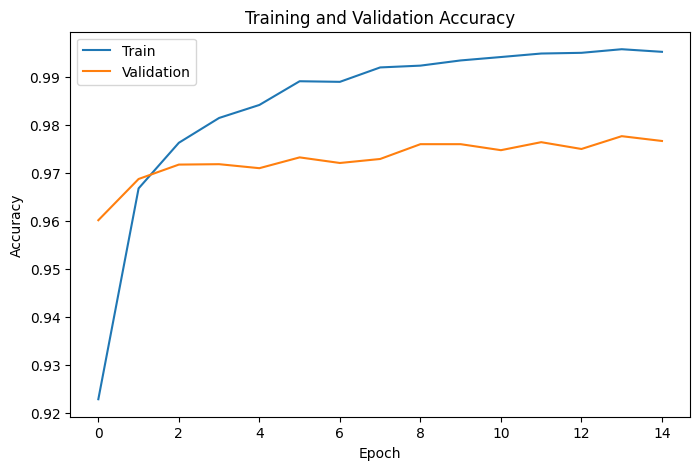

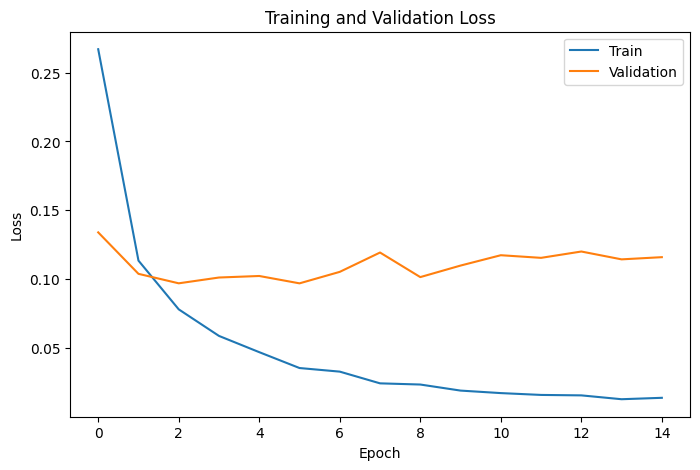

In [64]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

Q7.3

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - loss: 0.1133
Test Loss: 0.1133233979344368
Test Accuracy: 0.9757999777793884
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[ 961    0    1    1    1    3    2    2    2    7]
 [   0 1121    1    4    0    3    2    1    2    1]
 [   3    0  997   12    0    1    4    5    8    2]
 [   0    0    1  994    0    3    0    3    3    6]
 [   1    1    2    0  954    2    6    2    0   14]
 [   3    0    0   11    1  866    1    1    6    3]
 [   3    2    1    1    5    5  938    1    1    1]
 [   0    0    7    4    0    0    0 1010    2    5]
 [   1    1    2    4    2    6    1    2  947    8]
 [   1    2    0    5   19    3    0    8    1  970]]


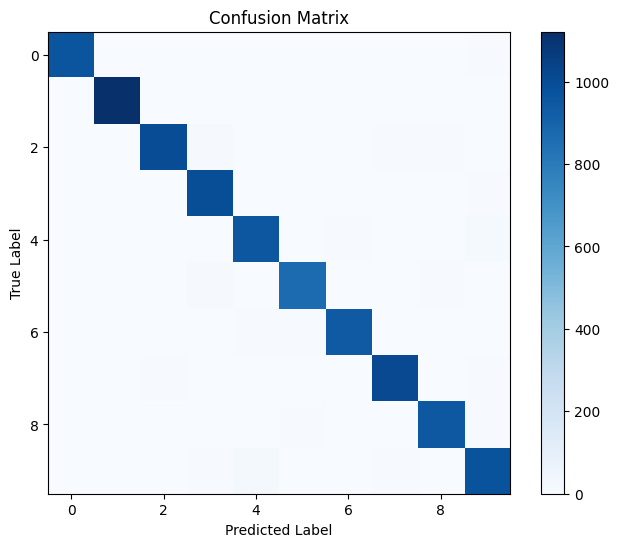

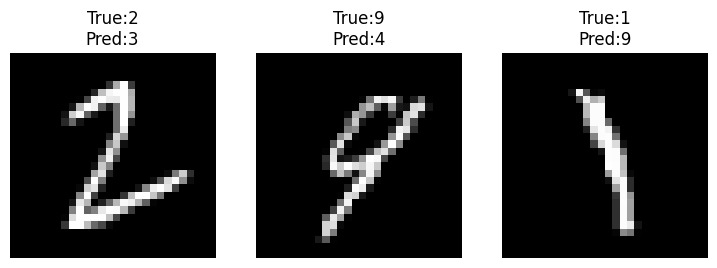

In [68]:
from sklearn.metrics import confusion_matrix

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

misclassified = np.where(y_test != y_pred)[0]

plt.figure(figsize=(9,3))

for i in range(3):
    idx = misclassified[i]

    plt.subplot(1,3,i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True:{y_test[idx]}\nPred:{y_pred[idx]}")
    plt.axis('off')

plt.show()

In [104]:
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

row, col = np.unravel_index(
    np.argmax(cm_copy),
    cm_copy.shape
)
print(row,col)

9 4


The confusion matrix shows that the digits 9 and 4 are among the most commonly confused pairs.
Other common confusions include 1 and 9, and 2 and 3.
Reson: Handwritten digits often vary significantly between individuals, causing some digits to resemble others.

Q7.4

In [69]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

In [70]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print("X_train shape:", X_train_cnn.shape)
print("X_test shape:", X_test_cnn.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [71]:
model_cnn = Sequential([

    Conv2D(
        32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [73]:
print("\nCNN MODEL SUMMARY")
model_cnn.summary()


CNN MODEL SUMMARY


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
history_cnn = model_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.9568 - loss: 0.1428 - val_accuracy: 0.9845 - val_loss: 0.0562
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9859 - loss: 0.0442 - val_accuracy: 0.9852 - val_loss: 0.0484
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9909 - loss: 0.0290 - val_accuracy: 0.9900 - val_loss: 0.0340
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9933 - loss: 0.0210 - val_accuracy: 0.9897 - val_loss: 0.0396
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 33ms/step - accuracy: 0.9944 - loss: 0.0168 - val_accuracy: 0.9900 - val_loss: 0.0415
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9958 - loss: 0.0121 - val_accuracy: 0.9884 - val_loss: 0.0414
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9970 - loss: 0.0091 - val_accuracy: 0.9921 - val_loss: 0.0353
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9974 -

In [75]:
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(
    X_test_cnn,
    y_test
)

print("\nCNN Test Loss:", test_loss_cnn)
print("CNN Test Accuracy:", test_acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9930 - loss: 0.0336

CNN Test Loss: 0.033560942858457565
CNN Test Accuracy: 0.9929999709129333


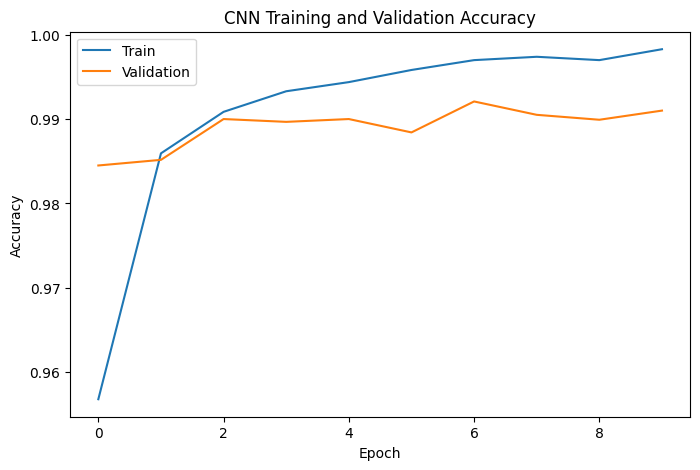

In [76]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

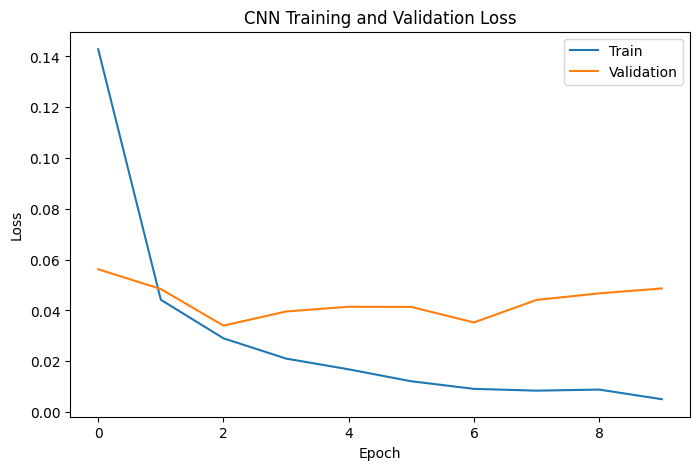

In [77]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [79]:
cnn_params = model_cnn.count_params()

ffnn_params = 109386      # From Q7.2

comparison = pd.DataFrame({

    "Model": ["Feedforward NN", "CNN"],

    "Parameters": [
        ffnn_params,
        cnn_params
    ],

    "Train Acc": [
        history.history['accuracy'][-1],
        history_cnn.history['accuracy'][-1]
    ],

    "Val Acc": [
        history.history['val_accuracy'][-1],
        history_cnn.history['val_accuracy'][-1]
    ],

    "Test Acc": [
        test_accuracy,
        test_acc_cnn
    ],

    "Epochs": [
        15,
        10
    ]
})

print("\nComparison Table")
print(comparison)


Comparison Table
            Model  Parameters  Train Acc   Val Acc  Test Acc  Epochs
0  Feedforward NN      109386   0.995146  0.976583    0.9758      15
1             CNN      225034   0.998271  0.991000    0.9930      10


CNN perform better than FNN because CNN preserves the spatial relationship between pixels and can identify edges, curves and shape using convolution filters wheres FNN loses the important information while flattening the image.